In [4]:
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sys


In [45]:
path="/data/rd_exchange/salbernhe/provinces/netcdf_monthly_provinces/provinces_Y1998_M10.nc"
ds= xr.open_dataset(path)
ds

<xarray.Dataset> Size: 35MB
Dimensions:    (latitude: 2040, longitude: 4320)
Coordinates:
  * latitude   (latitude) float32 8kB -80.0 -79.92 -79.83 ... 89.75 89.83 89.92
  * longitude  (longitude) float32 17kB -180.0 -179.9 -179.8 ... 179.8 179.9
Data variables:
    province   (latitude, longitude) float32 35MB ...
Attributes:
    title:        Regions biome T, Str, npp (from GLORYS/VGPM)
    institution:  CLS
    references:   http://www.cls.fr

## On ajoute une variable biome à chaque dataset



Création de nouveaux fichiers avec la variable biome dans le dataset_biome de rd_exchange

In [2]:
root = Path("/data/rd_exchange/salbernhe/provinces/netcdf_monthly_provinces")

output = Path("/data/rd_exchange/asauvebois/dataset_biome")


In [3]:

for file in sorted(root.glob("*.nc")):

    print(f"Traitement : {file.name}")


    ds = xr.open_dataset(file)

   
    ds["Biome"] = (ds["province"] // 100)


    outfile = output/ file.name


    ds.to_netcdf(outfile)

    ds.close()

Traitement : provinces_Y1998_M01.nc
Traitement : provinces_Y1998_M02.nc
Traitement : provinces_Y1998_M03.nc
Traitement : provinces_Y1998_M04.nc
Traitement : provinces_Y1998_M05.nc
Traitement : provinces_Y1998_M06.nc
Traitement : provinces_Y1998_M07.nc
Traitement : provinces_Y1998_M08.nc
Traitement : provinces_Y1998_M09.nc
Traitement : provinces_Y1998_M10.nc
Traitement : provinces_Y1998_M11.nc
Traitement : provinces_Y1998_M12.nc
Traitement : provinces_Y1999_M01.nc
Traitement : provinces_Y1999_M02.nc
Traitement : provinces_Y1999_M03.nc
Traitement : provinces_Y1999_M04.nc
Traitement : provinces_Y1999_M05.nc
Traitement : provinces_Y1999_M06.nc
Traitement : provinces_Y1999_M07.nc
Traitement : provinces_Y1999_M08.nc
Traitement : provinces_Y1999_M09.nc
Traitement : provinces_Y1999_M10.nc
Traitement : provinces_Y1999_M11.nc
Traitement : provinces_Y1999_M12.nc
Traitement : provinces_Y2000_M01.nc
Traitement : provinces_Y2000_M02.nc
Traitement : provinces_Y2000_M03.nc
Traitement : provinces_Y2000

In [4]:
path = "/data/rd_exchange/asauvebois/dataset_biome/provinces_Y1998_M01.nc"
ds =xr.open_dataset(path)
print(ds)

<xarray.Dataset> Size: 71MB
Dimensions:    (latitude: 2040, longitude: 4320)
Coordinates:
  * latitude   (latitude) float32 8kB -80.0 -79.92 -79.83 ... 89.75 89.83 89.92
  * longitude  (longitude) float32 17kB -180.0 -179.9 -179.8 ... 179.8 179.9
Data variables:
    province   (latitude, longitude) float32 35MB ...
    Biome      (latitude, longitude) float32 35MB ...
Attributes:
    title:        Regions biome T, Str, npp (from GLORYS/VGPM)
    institution:  CLS
    references:   http://www.cls.fr


## Mise en forme des données en dataset


On définit les chemins et les paramètres


In [3]:
provinces_folder = Path("/data/rd_exchange/asauvebois/dataset_biome") # est-ce que je le mets dans la boucle ou est-ce que je crée des dossiers avec l'ajout du biome ?
micronekton_folder = Path("/data/rd_exchange/asauvebois/moy_month")

variables_mnkc= ["mnkc_epi", "mnkc_umeso", "mnkc_lmeso", "mnkc_mumeso", "mnkc_mlmeso", "mnkc_hmlmeso"]


rows = []

Création du Dataset


In [6]:
for mnkc_file in sorted(micronekton_folder.glob("*_monthly_mean.nc")):

#on va extraire l'année et le mois depuis le nom du fichier
    year_str = mnkc_file.stem.split("_")[0]
    month_str = mnkc_file.stem.split("_")[1]
    print(f"\nTraitement {year_str}-{month_str}...")


#Fichier province correspondant

    prov_file = provinces_folder/f"provinces_Y{year_str}_M{month_str}.nc"

    if not prov_file.exists():
        print(f"   → Province manquante, on passe")
        continue

#on charge les deux datasets

    ds_mnkc = xr.open_dataset(mnkc_file)
    ds_prov = xr.open_dataset(prov_file)
    
    provinces = ds_prov["province"].values
    prov_list = list(set(provinces.flatten()))

#on boucle sur les provinces 
    prov_list = [p for p in set(provinces.flatten()) if not np.isnan(p)]

    for prov_id in prov_list:
        mask = (provinces == prov_id) #true si on est dans cette province
        biome_values = ds_prov["Biome"].values[mask]
        if len(biome_values) == 0:
            continue
        biome_id = ds_prov["Biome"].values[mask][0] #on prend toutes les valeurs de biome où le masque est true, et on prend la première car toutes les cases d'une même province ont le même biome
       
        row = {
            "date": f"{year_str}-{month_str}",
            "prov": prov_id,
            "Biome": biome_id
        }

#Puis on fait la moyenne spatiale de chaque variable sur la province

        for var in variables_mnkc:
            valeur = ds_mnkc[var].where(mask).mean().values
            row[var] = float(valeur)

        rows.append(row)


    ds_mnkc.close()
    ds_prov.close()


#création du Dataset
df = pd.DataFrame(rows)
df = df.set_index('date')
print(df)





Traitement 1998-01...

Traitement 1998-02...

Traitement 1998-03...

Traitement 1998-04...

Traitement 1998-05...

Traitement 1998-06...

Traitement 1998-07...

Traitement 1998-08...

Traitement 1998-09...

Traitement 1998-10...

Traitement 1998-11...

Traitement 1998-12...

Traitement 1999-01...

Traitement 1999-02...

Traitement 1999-03...

Traitement 1999-04...

Traitement 1999-05...

Traitement 1999-06...

Traitement 1999-07...

Traitement 1999-08...

Traitement 1999-09...

Traitement 1999-10...

Traitement 1999-11...

Traitement 1999-12...

Traitement 2000-01...

Traitement 2000-02...

Traitement 2000-03...

Traitement 2000-04...

Traitement 2000-05...

Traitement 2000-06...

Traitement 2000-07...

Traitement 2000-08...

Traitement 2000-09...

Traitement 2000-10...

Traitement 2000-11...

Traitement 2000-12...

Traitement 2001-01...

Traitement 2001-02...

Traitement 2001-03...

Traitement 2001-04...

Traitement 2001-05...

Traitement 2001-06...

Traitement 2001-07...

Traitement

In [7]:
df.to_csv("/data/rd_exchange/asauvebois/df_micronekton.csv")

Pour recharger le csv

In [9]:
df = pd.read_csv("/data/rd_exchange/asauvebois/dataset_global/df_micronekton.csv", index_col='date')
print(df)

          prov  Biome  mnkc_epi  mnkc_umeso  mnkc_lmeso  mnkc_mumeso  \
date                                                                   
1998-01  101.0    1.0  0.460964    0.614274    2.413278     0.796105   
1998-01  102.0    1.0  0.372419    0.556480    2.125784     0.659933   
1998-01  103.0    1.0  0.422545    0.630010    2.017993     0.685877   
1998-01  201.0    2.0  1.673023    1.051175    3.281833     1.990258   
1998-01  202.0    2.0  0.597547    0.426892    1.545762     0.668636   
...        ...    ...       ...         ...         ...          ...   
2023-12  503.0    5.0  1.108908    1.170073    2.385936     1.670662   
2023-12  502.0    5.0  2.671085    1.872016    4.097959     2.930487   
2023-12  601.0    6.0  0.689516    1.208844    2.158436     1.199348   
2023-12  602.0    6.0  2.949227    2.863782    4.445053     3.505710   
2023-12  603.0    6.0  7.217309    0.850936    0.932081     1.152758   

         mnkc_mlmeso  mnkc_hmlmeso  
date                      

## Analyse des données CSV

Avec Ncview, on voit bien que les moyennes caclulées sont cohérentes par rapport aux données mensuelles de biomasse par province.


## Tracé des données

In [76]:
df_mnkc = pd.read_csv("/data/rd_exchange/asauvebois/dataset_global/df_micronekton.csv", index_col='date', parse_dates= True)

df_mnkc[(df_mnkc.index.year == 2002) & (df_mnkc.index.month == 12)]


,prov,Biome,mnkc_epi,mnkc_umeso,mnkc_lmeso,mnkc_mumeso,mnkc_mlmeso,mnkc_hmlmeso
date,,,,,,,,
2002-12-01,101.0,1.0,0.485099,0.597357,2.545628,0.811749,1.075911,1.056441
2002-12-01,102.0,1.0,0.305408,0.529560,2.187233,0.585682,0.942862,0.767697
2002-12-01,103.0,1.0,0.509780,0.643327,2.060977,0.754419,1.026659,0.865017
2002-12-01,201.0,2.0,1.374448,0.948421,3.403709,1.761942,1.604234,2.090074
2002-12-01,203.0,2.0,0.882000,0.774758,2.389059,1.288209,1.233997,1.457852
2002-12-01,202.0,2.0,0.862057,0.540672,1.714476,0.887181,0.868139,1.006785
2002-12-01,205.0,2.0,1.013800,0.666485,1.987934,1.380934,1.037675,1.580455
2002-12-01,204.0,2.0,1.264026,0.824955,2.833716,1.370170,1.372250,1.632466
2002-12-01,301.0,3.0,2.405072,2.513139,5.115741,3.402269,3.372748,2.839227


on choisi les paramètres

In [25]:
biomass_selected = "mnkc_epi"
biome_selected = 6.0
print(df_mnkc.index.dtype)

str


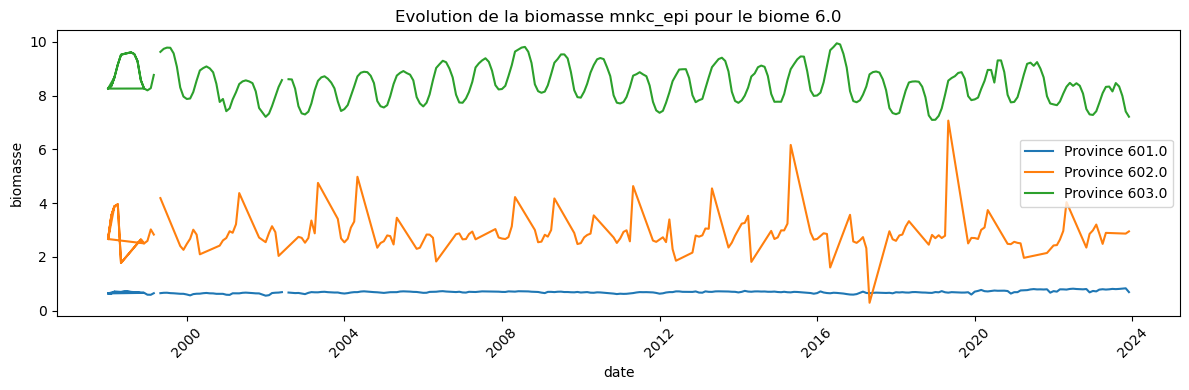

In [29]:
df_by_biome= df_mnkc[df_mnkc["Biome"] == biome_selected]

plt.figure(figsize = (12,4))

#on va tracer une courbe par province appartenant au biome choisi

for prov_id in df_by_biome['prov'].unique():
    df_prov= df_by_biome[df_by_biome['prov'] == prov_id]
    plt.plot(df_prov.index, df_prov[biomass_selected], label= f"Province {prov_id}")

plt.title(f"Evolution de la biomasse {biomass_selected} pour le biome {biome_selected}")
plt.xlabel("date")
plt.ylabel("biomasse")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



problème pour les premières valeurs...
Probablement lors du calcul des fichiers journaliers

In [48]:
mask_nan = df_mnkc.isna().any(axis=1)
print(df_mnkc[mask_nan])

             prov  Biome  mnkc_epi  mnkc_umeso  mnkc_lmeso  mnkc_mumeso  \
date                                                                      
1999-04-01  101.0    1.0       NaN         NaN         NaN          NaN   
1999-04-01  102.0    1.0       NaN         NaN         NaN          NaN   
1999-04-01  103.0    1.0       NaN         NaN         NaN          NaN   
1999-04-01  201.0    2.0       NaN         NaN         NaN          NaN   
1999-04-01  202.0    2.0       NaN         NaN         NaN          NaN   
...           ...    ...       ...         ...         ...          ...   
2022-03-01  502.0    5.0  2.155349    1.741027         NaN     2.524311   
2022-03-01  601.0    6.0  0.792879    1.205422         NaN     1.218879   
2022-03-01  602.0    6.0  2.643779    2.820987         NaN     3.171137   
2022-03-01  603.0    6.0  7.782441    0.839970         NaN     1.116278   
2023-05-01  602.0    6.0  2.894407    4.233093         NaN     3.154838   

            mnkc_mlmeso 